**1)IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_style("whitegrid")
RANDOM_STATE = 42

**2)DATA LOADING AND DATASET INSPECTION**

In [ ]:
df = pd.read_csv("D12_DataSet.tsv", sep="\t")

In [ ]:
print("--- 1. Total Rows and Columns (Shape) ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("-" * 30)


--- 1. Total Rows and Columns (Shape) ---
Total Rows: 140
Total Columns: 16
------------------------------


In [ ]:
print("\n------- 2. Column Names -------")
for i, col in enumerate(df.columns, 1):
    print("-" * 40)
    print(f"{i}) {col}")
print("=" * 40)


------- 2. Column Names -------
----------------------------------------
1) ssm_id
----------------------------------------
2) dna_change
----------------------------------------
3) protein_change
----------------------------------------
4) type
----------------------------------------
5) consequence
----------------------------------------
6) num_ssm_affected_cases
----------------------------------------
7) num_OTX1_cases
----------------------------------------
8) ssm_affected_cases_percentage
----------------------------------------
9) num_gdc_ssm_affected_cases
----------------------------------------
10) num_gdc_ssm_cases
----------------------------------------
11) gdc_ssm_affected_cases_percentage
----------------------------------------
12) vep_impact
----------------------------------------
13) sift_impact
----------------------------------------
14) sift_score
----------------------------------------
15) polyphen_impact
----------------------------------------
16) polyphen_

In [ ]:
print("\n--- 3. Dataset Info ---")
print(df.info())
print("=" * 40)


--- 3. Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ssm_id                             140 non-null    object 
 1   dna_change                         140 non-null    object 
 2   protein_change                     140 non-null    object 
 3   type                               140 non-null    object 
 4   consequence                        140 non-null    object 
 5   num_ssm_affected_cases             140 non-null    int64  
 6   num_OTX1_cases                     140 non-null    int64  
 7   ssm_affected_cases_percentage      140 non-null    float64
 8   num_gdc_ssm_affected_cases         140 non-null    int64  
 9   num_gdc_ssm_cases                  140 non-null    int64  
 10  gdc_ssm_affected_cases_percentage  140 non-null    float64
 11  vep_impact                       

In [ ]:
print("\n--- 4. First 5 Rows (Head) ---")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
print("=" * 40)


--- 4. First 5 Rows (Head) ---
| ssm_id                               | dna_change         | protein_change   | type         | consequence   | num_ssm_affected_cases   | num_OTX1_cases   | ssm_affected_cases_percentage   | num_gdc_ssm_affected_cases   | num_gdc_ssm_cases   | gdc_ssm_affected_cases_percentage   | vep_impact   | sift_impact   | sift_score   | polyphen_impact   | polyphen_score   |
|:-------------------------------------|:-------------------|:-----------------|:-------------|:--------------|:-------------------------|:-----------------|:--------------------------------|:-----------------------------|:--------------------|:------------------------------------|:-------------|:--------------|:-------------|:------------------|:-----------------|
| cfa38943-23c0-5053-a216-4e85de38eb15 | chr2:g.63054151C>T | OTX1 R68W        | Substitution | Missense      | 4                        | 2853             | 0.14                            | 4                            | 17075    

In [ ]:
print("\n--- 5. Other Important Inspections ---")
print("[ Missing Values per Column ]")
print(df.isnull().sum())
print("-" * 100)



--- 5. Other Important Inspections ---
[ Missing Values per Column ]
ssm_id                                0
dna_change                            0
protein_change                        0
type                                  0
consequence                           0
num_ssm_affected_cases                0
num_OTX1_cases                        0
ssm_affected_cases_percentage         0
num_gdc_ssm_affected_cases            0
num_gdc_ssm_cases                     0
gdc_ssm_affected_cases_percentage     0
vep_impact                            0
sift_impact                          60
sift_score                           60
polyphen_impact                      60
polyphen_score                       60
dtype: int64
----------------------------------------------------------------------------------------------------


In [ ]:
print(f"[ Duplicated Rows ]: {df.duplicated().sum()}")
print("-" * 100)


[ Duplicated Rows ]: 0
----------------------------------------------------------------------------------------------------


In [ ]:
print("[ Statistical Summary ]")
print(df.describe())
print("=" * 100)

[ Statistical Summary ]
       num_ssm_affected_cases  num_OTX1_cases  ssm_affected_cases_percentage  \
count              140.000000           140.0                     140.000000   
mean                 1.092857          2853.0                       0.042857   
std                  0.357779             0.0                       0.011334   
min                  1.000000          2853.0                       0.040000   
25%                  1.000000          2853.0                       0.040000   
50%                  1.000000          2853.0                       0.040000   
75%                  1.000000          2853.0                       0.040000   
max                  4.000000          2853.0                       0.140000   

       num_gdc_ssm_affected_cases  num_gdc_ssm_cases  \
count                  140.000000              140.0   
mean                     1.092857            17075.0   
std                      0.357779                0.0   
min                      1.0000

**3)DATA CLEANING**

In [ ]:
print("\n ----Removing Duplicates-----")
initial_rows = df.shape[0]
print(f"Duplicates present :{df.duplicated().sum()} ")
df = df.drop_duplicates()
print(f"Duplicates removed: {initial_rows - df.shape[0]}")


 ----Removing Duplicates-----
Duplicates present :0 
Duplicates removed: 0


In [ ]:
synonymous_mask = df['consequence'] == 'Synonymous'

print(f"Missing SIFT score before: {df['sift_score'].isnull().sum()}")
df.loc[synonymous_mask, 'sift_score'] = df.loc[synonymous_mask, 'sift_score'].fillna(1.0)
print(f"Missing SIFT score after logic fill: {df['sift_score'].isnull().sum()}")
df['sift_score'] = df['sift_score'].fillna(df['sift_score'].median())
print(f"Missing SIFT score Final: {df['sift_score'].isnull().sum()}")
print("-" * 40)

print(f"Missing SIFT impact before: {df['sift_impact'].isnull().sum()}")
df.loc[synonymous_mask, 'sift_impact'] = df.loc[synonymous_mask, 'sift_impact'].fillna('tolerated')
print(f"Missing SIFT impact after logic fill: {df['sift_impact'].isnull().sum()}")
df['sift_impact'] = df['sift_impact'].fillna(df['sift_impact'].mode()[0])
print(f"Missing SIFT impact Final: {df['sift_impact'].isnull().sum()}")
print("-" * 40)

print(f"Missing Polyphen score before: {df['polyphen_score'].isnull().sum()}")
df.loc[synonymous_mask, 'polyphen_score'] = df.loc[synonymous_mask, 'polyphen_score'].fillna(0.0)
print(f"Missing Polyphen score after logic fill: {df['polyphen_score'].isnull().sum()}")
df['polyphen_score'] = df['polyphen_score'].fillna(df['polyphen_score'].median())
print(f"Missing Polyphen score Final: {df['polyphen_score'].isnull().sum()}")
print("-" * 40)

print(f"Missing Polyphen impact before: {df['polyphen_impact'].isnull().sum()}")
df.loc[synonymous_mask, 'polyphen_impact'] = df.loc[synonymous_mask, 'polyphen_impact'].fillna('benign')
print(f"Missing Polyphen impact after logic fill: {df['polyphen_impact'].isnull().sum()}")
df['polyphen_impact'] = df['polyphen_impact'].fillna(df['polyphen_impact'].mode()[0])
print(f"Missing Polyphen impact Final: {df['polyphen_impact'].isnull().sum()}")
print("=" * 40)

Missing SIFT score before: 60
Missing SIFT score after logic fill: 14
Missing SIFT score Final: 0
----------------------------------------
Missing SIFT impact before: 60
Missing SIFT impact after logic fill: 14
Missing SIFT impact Final: 0
----------------------------------------
Missing Polyphen score before: 60
Missing Polyphen score after logic fill: 14
Missing Polyphen score Final: 0
----------------------------------------
Missing Polyphen impact before: 60
Missing Polyphen impact after logic fill: 14
Missing Polyphen impact Final: 0


In [ ]:
print("Rechecking for missing values")
print(df.isnull().sum())

Rechecking for missing values
ssm_id                               0
dna_change                           0
protein_change                       0
type                                 0
consequence                          0
num_ssm_affected_cases               0
num_OTX1_cases                       0
ssm_affected_cases_percentage        0
num_gdc_ssm_affected_cases           0
num_gdc_ssm_cases                    0
gdc_ssm_affected_cases_percentage    0
vep_impact                           0
sift_impact                          0
sift_score                           0
polyphen_impact                      0
polyphen_score                       0
dtype: int64


**4)DATA VISUALIZATION**

/tmp/ipykernel_858/566334127.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='vep_impact', data=df, palette='viridis', order=df['vep_impact'].value_counts().index)
/tmp/ipykernel_858/566334127.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='consequence', data=df, palette='magma', order=df['consequence'].value_counts().index)


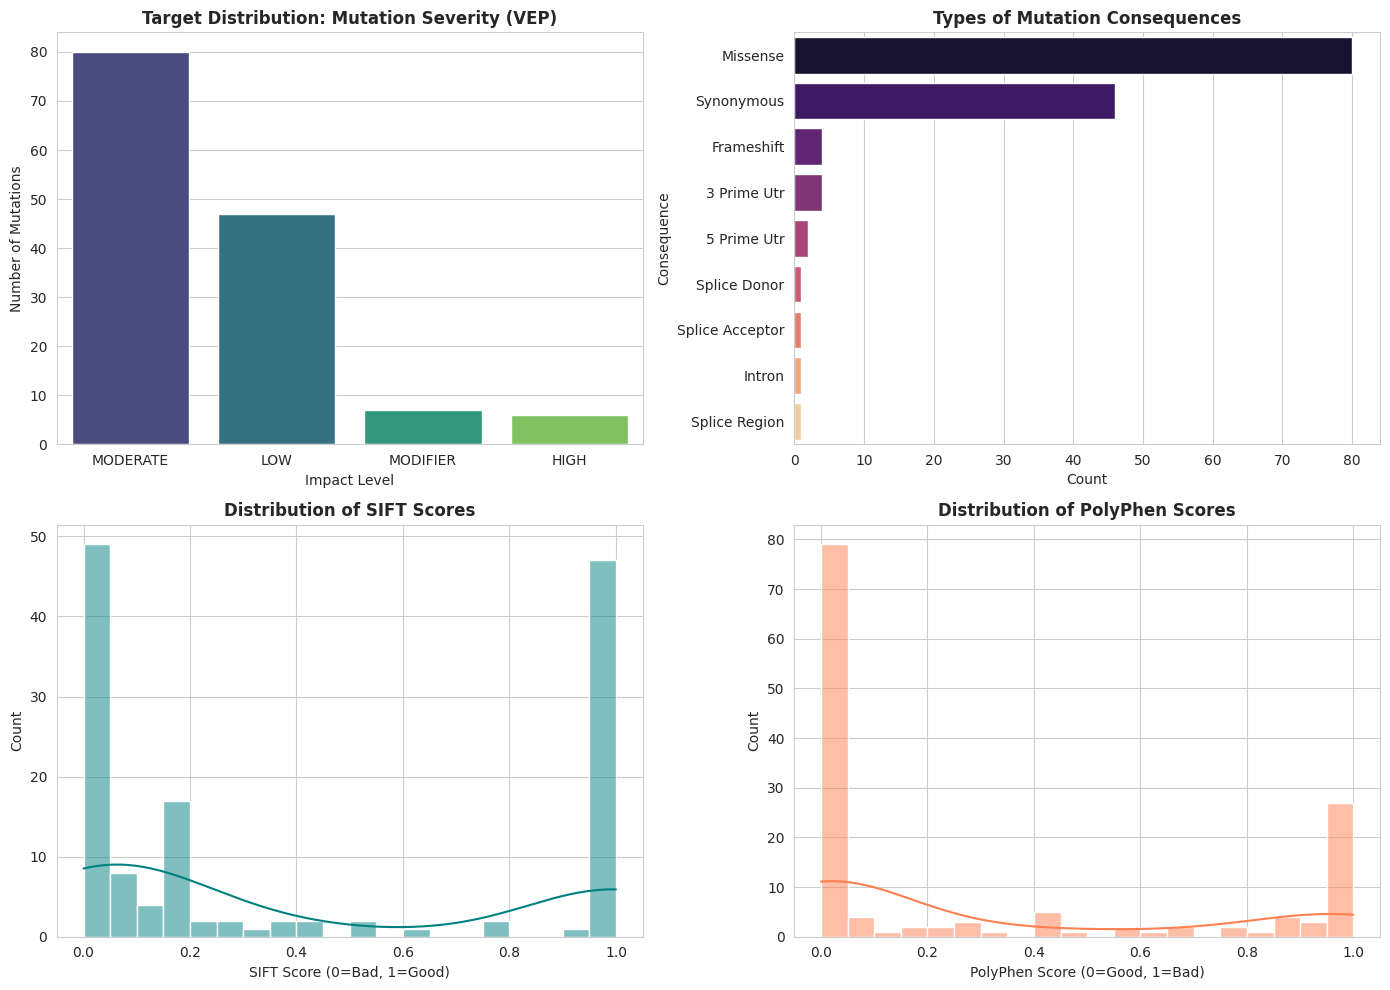

--- Exact Counts for Target Class ---
vep_impact
MODERATE    80
LOW         47
MODIFIER     7
HIGH         6
Name: count, dtype: int64


In [ ]:
# ==========================================
# STEP 4: DATASET DISTRIBUTION ANALYSIS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_style("whitegrid")
plt.figure(figsize=(14, 10))

# 1. Target Variable Distribution (VEP Impact)
# This checks for Class Imbalance (Crucial for ML)
plt.subplot(2, 2, 1)
sns.countplot(x='vep_impact', data=df, palette='viridis', order=df['vep_impact'].value_counts().index)
plt.title('Target Distribution: Mutation Severity (VEP)', fontsize=12, fontweight='bold')
plt.xlabel('Impact Level')
plt.ylabel('Number of Mutations')

# 2. Mutation Consequence Distribution
# Shows the biological types (Missense vs Synonymous, etc.)
plt.subplot(2, 2, 2)
sns.countplot(y='consequence', data=df, palette='magma', order=df['consequence'].value_counts().index)
plt.title('Types of Mutation Consequences', fontsize=12, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Consequence')

# 3. SIFT Score Distribution (Histogram)
# Shows the spread of damage predictions (0.0 = Damaging, 1.0 = Tolerated)
plt.subplot(2, 2, 3)
sns.histplot(df['sift_score'], kde=True, color='teal', bins=20)
plt.title('Distribution of SIFT Scores', fontsize=12, fontweight='bold')
plt.xlabel('SIFT Score (0=Bad, 1=Good)')

# 4. PolyPhen Score Distribution (Histogram)
# Shows the spread of damage predictions (0.0 = Benign, 1.0 = Damaging)
plt.subplot(2, 2, 4)
sns.histplot(df['polyphen_score'], kde=True, color='coral', bins=20)
plt.title('Distribution of PolyPhen Scores', fontsize=12, fontweight='bold')
plt.xlabel('PolyPhen Score (0=Good, 1=Bad)')

plt.tight_layout()
plt.show()

# Print the exact counts for the Target Variable
print("--- Exact Counts for Target Class ---")
print(df['vep_impact'].value_counts())
print("=" * 40)

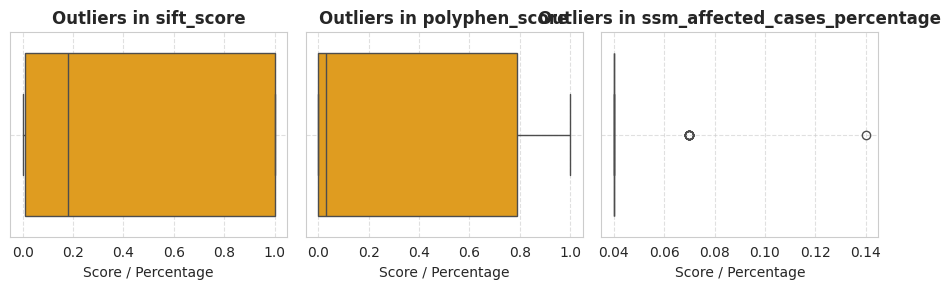


--- Outlier Statistical Check (Min/Max) ---
Feature: sift_score
  Min: 0.0
  Max: 1.0
------------------------------
Feature: polyphen_score
  Min: 0.0
  Max: 1.0
------------------------------
Feature: ssm_affected_cases_percentage
  Min: 0.04
  Max: 0.14
------------------------------
----------------------------------------


In [ ]:


outlier_cols = ['sift_score', 'polyphen_score', 'ssm_affected_cases_percentage']


plt.figure(figsize=(9,3))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Score / Percentage')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n--- Outlier Statistical Check (Min/Max) ---")
for col in outlier_cols:
    print(f"Feature: {col}")
    print(f"  Min: {df[col].min()}")
    print(f"  Max: {df[col].max()}")
    print("-" * 30)
print("=" * 40)

col_name = 'ssm_affected_cases_percentage'
upper_limit = df[col_name].quantile(0.95)
lower_limit = df[col_name].quantile(0.05)
df[col_name] = df[col_name].clip(lower=lower_limit, upper=upper_limit)

print("-" * 40)

In [ ]:

df = df.drop(columns=['dna_change'])
df = df.drop(columns=['protein_change'])
df = df.drop(columns=['sift_score'])
df = df.drop(columns=['polyphen_score'])

cols_to_remove = [
    'num_ssm_affected_cases',
    'num_OTX1_cases',
    'ssm_affected_cases_percentage',
    'num_gdc_ssm_affected_cases',
    'num_gdc_ssm_cases',
    'gdc_ssm_affected_cases_percentage'
]

df.drop(columns=cols_to_remove, inplace=True)

print("Columns removed successfully")
print(df.head().to_markdown(index=False))



Columns removed successfully
| ssm_id                               | type         | consequence   | vep_impact   | sift_impact   | polyphen_impact   |
|:-------------------------------------|:-------------|:--------------|:-------------|:--------------|:------------------|
| cfa38943-23c0-5053-a216-4e85de38eb15 | Substitution | Missense      | MODERATE     | deleterious   | probably_damaging |
| 1c4d6d6c-a225-51c8-9278-1756937e40d1 | Substitution | Missense      | MODERATE     | deleterious   | probably_damaging |
| 2fc3cb44-ceaa-546c-b80d-47b82edd29d6 | Substitution | Synonymous    | LOW          | tolerated     | benign            |
| 392d9865-b802-53cd-ab24-ac9e7d6b2bb1 | Substitution | Missense      | MODERATE     | deleterious   | probably_damaging |
| 4ade47c2-01c3-54e7-8e0c-94034b0b4da5 | Substitution | Synonymous    | LOW          | tolerated     | benign            |


In [ ]:
df.head()

,ssm_id,type,consequence,vep_impact,sift_impact,polyphen_impact
0,cfa38943-23c0-5053-a216-4e85de38eb15,Substitution,Missense,MODERATE,deleterious,probably_damaging
1,1c4d6d6c-a225-51c8-9278-1756937e40d1,Substitution,Missense,MODERATE,deleterious,probably_damaging
2,2fc3cb44-ceaa-546c-b80d-47b82edd29d6,Substitution,Synonymous,LOW,tolerated,benign
3,392d9865-b802-53cd-ab24-ac9e7d6b2bb1,Substitution,Missense,MODERATE,deleterious,probably_damaging
4,4ade47c2-01c3-54e7-8e0c-94034b0b4da5,Substitution,Synonymous,LOW,tolerated,benign


**5)LABEL ENCODING**

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 'ssm_id' was already dropped in a previous cell, so no need to drop it again here.

# Extract the target variable 'vep_impact' before one-hot encoding the features
y = df['vep_impact']

# Select object (categorical) columns for features
obj_cols_features = df.select_dtypes(include=['object']).columns.drop('vep_impact')

# Apply One-Hot Encoding to the feature columns only
X = pd.get_dummies(df.drop(columns=['vep_impact']), columns=obj_cols_features, drop_first=False)

# Use LabelEncoder for the target variable 'y'
le = LabelEncoder()
y = le.fit_transform(y)

print("Shape of X (features):")
print(X.shape)
print("Shape of y (target):")
print(y.shape)
print("Encoded target classes:")
print(le.classes_)

print("-" * 40)
print(X.head().to_markdown(index=False))

KeyError: 'vep_impact'

**6)5-FOLD VALIDATION**

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# X and y are already prepared in the previous cell

for i, (train_index, test_index) in enumerate(cv.split(X, y), 1):
    train_size = len(train_index)
    test_size = len(test_index)
    percent = test_size / (train_size + test_size)

NameError: name 'X' is not defined

**7)ML**

In [ ]:

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty='elasticnet', solver='saga', l1_ratio=0.5, C=0.5,
        max_iter=5000, class_weight='balanced', random_state=42
    )
)

# 2. Define Metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

# 3. Run Validation
scores = cross_validate(model, X, y, cv=cv, scoring=scoring)

# 4. Calculate Average Scores
acc = scores['test_accuracy'].mean()
prec = scores['test_precision'].mean()
rec = scores['test_recall'].mean()
f1 = scores['test_f1'].mean()
error = 1 - acc  # Error Rate calculation

# 5. Print Results
print("-" * 30)
print(f"Accuracy:  {acc:.2%}")
print(f"Precision: {prec:.2%}")
print(f"Recall:    {rec:.2%}")
print(f"F1 Score:  {f1:.2%}")
print(f"Error:     {error:.2%}")
print("-" * 30)

NameError: name 'X' is not defined

In [ ]:


from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 1. Define the SVM Model
# - kernel='rbf': Handles complex, non-linear biological patterns
# - C=1.0: Standard regularization
# - class_weight='balanced': Crucial for handling the rare 'HIGH' impact mutations
model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
)

# 2. Define Validation Strategy (if not already defined)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Define Metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

# 4. Run Validation
print("Running SVM Validation...")
scores = cross_validate(model, X, y, cv=cv, scoring=scoring)

# 5. Calculate Average Scores
acc = scores['test_accuracy'].mean()
prec = scores['test_precision'].mean()
rec = scores['test_recall'].mean()
f1 = scores['test_f1'].mean()
error = 1 - acc  # Error Rate

# 6. Print Results
print("-" * 30)
print(f"Accuracy:  {acc:.2%}")
print(f"Precision: {prec:.2%}")
print(f"Recall:    {rec:.2%}")
print(f"F1 Score:  {f1:.2%}")
print(f"Error:     {error:.2%}")
print("-" * 30)

In [ ]:
# ==========================================
# STEP 10: DETAILED 5-FOLD VALIDATION (RANDOM FOREST)
# ==========================================

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# 1. Define the Random Forest Model
# - n_estimators=100: Number of trees
# - max_depth=5: Pruning (keeps the model simple for small data)
# - class_weight='balanced': Handles the rare mutation types
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

# 2. Define Validation Strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Define Metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

# 4. Run Validation
print("Running Random Forest Validation...")
scores = cross_validate(model, X, y, cv=cv, scoring=scoring)

# 5. Calculate Average Scores
acc = scores['test_accuracy'].mean()
prec = scores['test_precision'].mean()
rec = scores['test_recall'].mean()
f1 = scores['test_f1'].mean()
error = 1 - acc  # Error Rate

# 6. Print Results
print("-" * 30)
print(f"Accuracy:  {acc:.2%}")
print(f"Precision: {prec:.2%}")
print(f"Recall:    {rec:.2%}")
print(f"F1 Score:  {f1:.2%}")
print(f"Error:     {error:.2%}")
print("-" * 30)

**9)EPOCHS GRAPHS**

In [ ]:
# ==========================================
# STEP 16: COMBINED ACCURACY & ERROR PLOTS
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import warnings

# Suppress warnings for early stopping
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# --- 1. SETUP RANGES ---
# Random Forest "Epochs" = n_estimators (1 to 300)
rf_epochs = [1, 5, 10, 20, 50, 100, 150, 200, 300]

# Linear Models "Epochs" = max_iter (10 to 3000)
# We align the sizes roughly so they can be plotted together conceptually
linear_epochs = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000]

# Storage for scores
acc_rf, acc_lr, acc_svm = [], [], []
err_rf, err_lr, err_svm = [], [], []

print("Running Simulations...")

# --- 2. RUN RANDOM FOREST ---
print("1. Training Random Forest...")
for n in rf_epochs:
    model = RandomForestClassifier(n_estimators=n, max_depth=5, class_weight='balanced', random_state=42)
    acc = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    acc_rf.append(acc)
    err_rf.append(1 - acc)

# --- 3. RUN ELASTIC NET LR ---
print("2. Training Elastic Net LR...")
for n in linear_epochs:
    model = make_pipeline(StandardScaler(), LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=n, class_weight='balanced', random_state=42))
    acc = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    acc_lr.append(acc)
    err_lr.append(1 - acc)

# --- 4. RUN SVM ---
print("3. Training SVM...")
for n in linear_epochs:
    model = make_pipeline(StandardScaler(), SVC(kernel='rbf', max_iter=n, class_weight='balanced', random_state=42))
    acc = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    acc_svm.append(acc)
    err_svm.append(1 - acc)

# --- 5. PLOTTING ---
plt.figure(figsize=(16, 6))

# GRAPH 1: ACCURACY vs EPOCHS
plt.subplot(1, 2, 1)
plt.plot(rf_epochs, acc_rf, 'o-', color='green', linewidth=2, label='Random Forest (Trees)')
plt.plot(linear_epochs, acc_lr, 's-', color='blue', linewidth=2, label='Elastic Net (Iter)')
plt.plot(linear_epochs, acc_svm, '^-', color='red', linewidth=2, label='SVM (Iter)')

plt.title('Model Accuracy vs. Epochs (Training Complexity)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs (Trees / Iterations)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xscale('log') # Log scale handles the difference between 100 trees and 3000 iterations
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# GRAPH 2: ERROR vs EPOCHS
plt.subplot(1, 2, 2)
plt.plot(rf_epochs, err_rf, 'o-', color='green', linewidth=2, label='Random Forest')
plt.plot(linear_epochs, err_lr, 's-', color='blue', linewidth=2, label='Elastic Net')
plt.plot(linear_epochs, err_svm, '^-', color='red', linewidth=2, label='SVM')

plt.title('Model Error vs. Epochs (Lower is Better)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs (Trees / Iterations)', fontsize=12)
plt.ylabel('Error Rate (1.0 - Accuracy)', fontsize=12)
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()